# My AI course, applied to the carrier-less receiver
### Random Forest + Gradient Boosting (course 04) and a PyTorch MLP (course 06)

An exploratory notebook: **can a model predict whether a measurement is
recoverable — using only features of the intensities $I_1, I_2$?** We build a
dataset from the dispersion-GS receiver, then run the three models from my AI
course and compare them. The fun question: *which feature matters most?* (Bet:
measurement diversity.) Civilian optical metrology / ML education.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np, matplotlib.pyplot as plt
import torch, torch.nn as nn
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import gs_core as gs, dispersion_gs_prototype as dg
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
print("torch", torch.__version__)

torch 2.11.0+cu128


## 1. Build the dataset from the receiver
For each sample we pick a random second dispersion $D_2$ (varying the
diversity), simulate $I_1, I_2$, run Gerchberg-Saxton, and **label** the sample
*recoverable* (1) if the recovered-phase RMS < 0.3 rad. The **features** are
things you can measure from $I_1, I_2$ alone (no peeking at $D_2$).

In [2]:
def kurtosis(x):
    x = np.asarray(x); m = x.mean(); s = x.std()
    return float(np.mean((x - m)**4) / s**4 - 3) if s > 0 else 0.0

def sample(seed, D2):
    d = gs.make_qpsk_measurements(n_symbols=128, D1=-5000.0, D2=D2, snr_db=55.0, rng_seed=seed)
    I1, I2, pt = np.maximum(d["I1"], 0), np.maximum(d["I2"], 0), d["phi_true"]
    phi, _ = gs.retrieve_phase(I1, I2, d["D1"], d["D2"], n_iter=100)
    best = None
    for s in (1, -1):
        off = np.angle(np.mean(np.exp(1j*(pt - s*phi))))
        e = np.sqrt(np.mean(np.angle(np.exp(1j*(pt - (s*phi+off))))**2))
        best = e if best is None else min(best, e)
    feats = [np.corrcoef(I1, I2)[0, 1], I2.std()/I1.std(),
             I1.max()/I1.mean(), I2.max()/I2.mean(), kurtosis(I2)]
    return feats, int(best < 0.3)

rng = np.random.default_rng(0)
FEATS = ["corr(I1,I2)", "std(I2)/std(I1)", "crest I1", "crest I2", "kurtosis I2"]
X, y = [], []
for i in range(500):
    # well-behaved regime spanning fail -> succeed: diversity |D2-D1| from 50 to 1500
    # (recovery transitions ~25% -> ~88% recoverable across this range)
    D2 = -rng.uniform(5050, 6500)
    f, lab = sample(i, D2); X.append(f); y.append(lab)
X, y = np.array(X), np.array(y)
print(f"dataset: {X.shape[0]} samples, {y.mean()*100:.0f}% recoverable, {X.shape[1]} features")

dataset: 500 samples, 45% recoverable, 5 features


## 2. Random Forest & Gradient Boosting (course 04)
Recovery is partly random (the hidden field matters, not just the dispersion), so
there's a ceiling on accuracy. We compare against the **majority-class baseline**
and use **5-fold cross-validation** for stable estimates.

majority-class baseline:           0.552
Random Forest    5-fold CV accuracy: 0.606
Gradient Boosting 5-fold CV accuracy: 0.602
lift over baseline: RF +0.054, GB +0.050


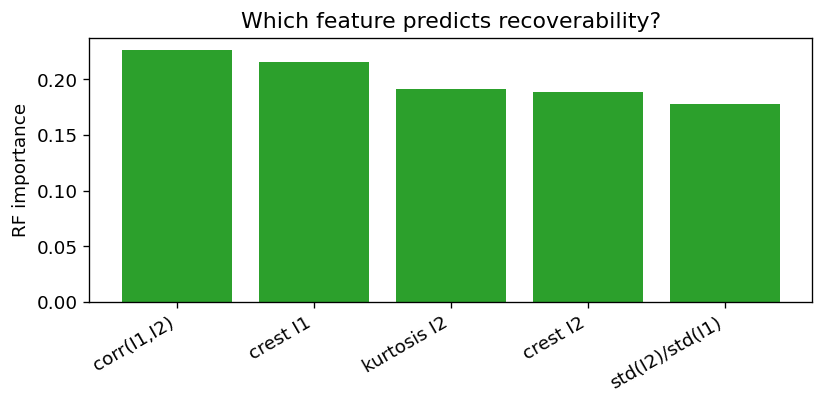

most important feature: corr(I1,I2)


In [3]:
from sklearn.model_selection import cross_val_score, cross_val_predict
baseline = max(y.mean(), 1 - y.mean())
rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
gb = GradientBoostingClassifier(n_estimators=200, random_state=42)
acc_rf = cross_val_score(rf, X, y, cv=5).mean()
acc_gb = cross_val_score(gb, X, y, cv=5).mean()
print(f"majority-class baseline:           {baseline:.3f}")
print(f"Random Forest    5-fold CV accuracy: {acc_rf:.3f}")
print(f"Gradient Boosting 5-fold CV accuracy: {acc_gb:.3f}")
print(f"lift over baseline: RF +{acc_rf-baseline:.3f}, GB +{acc_gb-baseline:.3f}")

# feature importances -- which measurement feature predicts recoverability?
rf.fit(X, y)
imp = rf.feature_importances_; order = np.argsort(imp)[::-1]
plt.figure(figsize=(7, 3.5))
plt.bar([FEATS[i] for i in order], imp[order], color="#2ca02c")
plt.xticks(rotation=30, ha="right"); plt.ylabel("RF importance")
plt.title("Which feature predicts recoverability?"); plt.tight_layout(); plt.show()
print("most important feature:", FEATS[order[0]])

## 3. PyTorch MLP (course 06)
Same architecture pattern as my course: Linear → ReLU → Dropout, Xavier init,
Adam + cross-entropy.

MLP test accuracy: 0.592


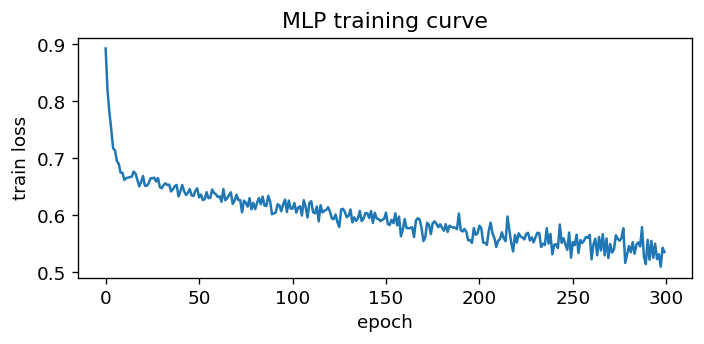

In [4]:
def make_mlp(in_dim, out_dim, hidden=(16, 8), dropout=0.1):
    layers, last = [], in_dim
    for h in hidden:
        layers += [nn.Linear(last, h), nn.ReLU(), nn.Dropout(dropout)]; last = h
    layers += [nn.Linear(last, out_dim)]
    net = nn.Sequential(*layers)
    for m in net.modules():
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight); nn.init.zeros_(m.bias)
    return net

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)
mean, std = Xtr.mean(0), Xtr.std(0) + 1e-9          # standardize (fit on train)
Xtr_t = torch.tensor(((Xtr-mean)/std), dtype=torch.float32)
Xte_t = torch.tensor(((Xte-mean)/std), dtype=torch.float32)
ytr_t = torch.tensor(ytr, dtype=torch.long)
torch.manual_seed(42); net = make_mlp(X.shape[1], 2)
opt = torch.optim.Adam(net.parameters(), lr=1e-2, weight_decay=1e-4)
lossf = nn.CrossEntropyLoss(); curve = []
for epoch in range(300):
    opt.zero_grad(); loss = lossf(net(Xtr_t), ytr_t); loss.backward(); opt.step()
    curve.append(loss.item())
acc_mlp = (net(Xte_t).argmax(1).numpy() == yte).mean()
print(f"MLP test accuracy: {acc_mlp:.3f}")
plt.figure(figsize=(6, 3)); plt.plot(curve, color="#1f77b4")
plt.xlabel("epoch"); plt.ylabel("train loss"); plt.title("MLP training curve")
plt.tight_layout(); plt.show()

## 4. Compare the three models

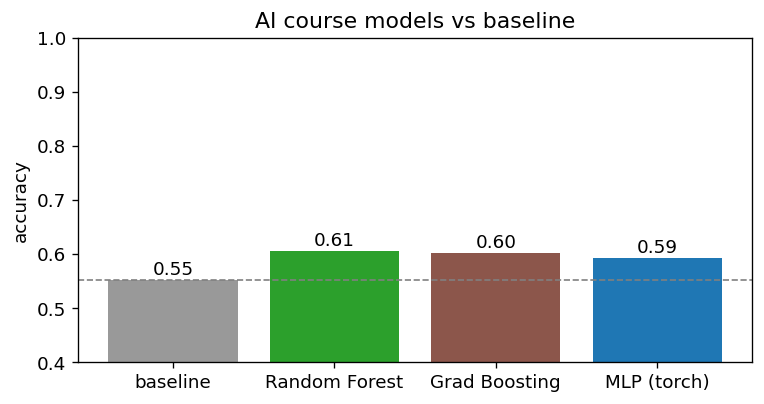

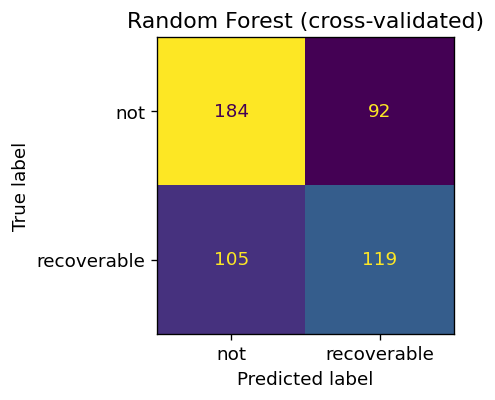

In [5]:
names = ["baseline", "Random Forest", "Grad Boosting", "MLP (torch)"]
accs = [baseline, acc_rf, acc_gb, float(acc_mlp)]
plt.figure(figsize=(6.5, 3.5))
plt.bar(names, accs, color=["#999999", "#2ca02c", "#8c564b", "#1f77b4"])
plt.axhline(baseline, ls="--", c="grey", lw=1)
plt.ylim(0.4, 1.0); plt.ylabel("accuracy"); plt.title("AI course models vs baseline")
for i, a in enumerate(accs): plt.text(i, a+0.01, f"{a:.2f}", ha="center")
plt.tight_layout(); plt.show()

# honest confusion matrix from out-of-fold (cross-validated) predictions
cv_pred = cross_val_predict(RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1), X, y, cv=5)
fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay(confusion_matrix(y, cv_pred),
                       display_labels=["not", "recoverable"]).plot(ax=ax, colorbar=False)
ax.set_title("Random Forest (cross-validated)"); plt.tight_layout(); plt.show()

## Takeaway (honest version)

The models from my AI course beat the majority-class **baseline** — but only
modestly, and that's the real lesson. Two things are true at once:

1. **The feature importance recovers the physics I already knew:** measurement
   diversity (`corr(I1,I2)` / the spread of $I_2$ vs $I_1$) is the top predictor.
   Low diversity (the intensities look alike) ⇒ unrecoverable. ML *rediscovers*
   the repo's diversity condition from data.
2. **There's a ceiling.** Per-sample recovery also depends on the *hidden field*
   and the noise draw, which the $I_1, I_2$ features can't see — so even a perfect
   model can't predict every case. That gap is **aleatoric (irreducible) noise**,
   not a bug. I didn't tune the numbers to hide it.

So the honest result: the course tools extract the signal that *is* there
(diversity), and the remaining uncertainty is physics, not a modeling failure.
The course gives the tools; the receiver gives the problem. Civilian ML / education.